In [1]:
import os
import sys
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.autograd import Variable
from sklearn import random_projection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.random_projection import johnson_lindenstrauss_min_dim
from latent_regularizer import*

In [2]:
# intialize parameters 
gmm_std = 2
num_centers = 4
random_seed = 42
batch_size = 128
num_samples = 100
gaussian_range = 30
output_data_folder = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr'
# output_data_folder = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice'

In [3]:
# set random seed 
random.seed(random_seed)

In [4]:
def draw_gmm_samples(num_samples, gmm_centers, gmm_std):
    num_gmm_centers, dimension = gmm_centers.shape
    print(num_gmm_centers, dimension)
    samples = []
    components = []
    for _ in range(num_samples):
        component = np.random.choice(range(num_gmm_centers))

        component_mean = gmm_centers[component, :]
        component_cov = torch.eye(dimension) * gmm_std

        distribution = torch.distributions.multivariate_normal.MultivariateNormal(
            loc=component_mean, covariance_matrix=component_cov)

        sample = distribution.sample((1,))
        samples.append(sample)
        components.append(component)
    samples = torch.vstack(samples)

    return samples, components

In [5]:
def generate_gmm_centers(num_pairs, range_start, gaussian_range, num_centers):
    unique_pairs = []
    for _ in range(num_pairs):
        nums = []
        inc = int(gaussian_range / num_centers)
        for center in range(num_centers):
            num = random.uniform(range_start + inc * center, range_start + inc * (center + 1))
            nums.append(num)
        unique_pairs.append(nums)
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

In [6]:
# def generate_5_gmm_centers(num_pairs, range_start):
#     import random
#     unique_pairs = []
#     for _ in range(num_pairs):
#         num1 = random.uniform(range_start, range_start+6)
#         num2 = random.uniform(range_start+6, range_start+12)
#         num3 = random.uniform(range_start+12, range_start+18)
#         num4 = random.uniform(range_start+18, range_start+24)
#         num5 = random.uniform(range_start+24, range_start+30)
#         unique_pairs.append((num1, num2, num3, num4, num5))
#     gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
#     return gmm_centers

In [21]:
def gaussian_sample(num_samples, gaussian_range, num_centers):
    startpoint = random.randint(-30,0)
    gmm_centers = generate_gmm_centers(10, startpoint, gaussian_range, num_centers)
    print(gmm_centers.numpy())
    global gmm_std
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std

[[-22.263103   -26.79142    -25.608137   -22.875141   -22.113024
  -24.643839   -22.773918   -20.18819    -22.670362   -26.67923   ]
 [-13.754743   -18.469534   -15.450809   -14.333987   -17.618246
  -19.350779   -14.350102   -17.35026    -13.968052   -18.404713  ]
 [-12.391428    -9.462513    -9.18541    -12.954509   -11.911643
  -12.322986    -7.8918777   -9.1357155   -8.958535   -10.974284  ]
 [ -3.0465472   -5.814248    -4.456916    -0.35926524   0.7004915
   -0.06753944  -2.2464035   -0.19416735  -1.0679971   -5.4414563 ]]
Standard deviation used: 2
4 10


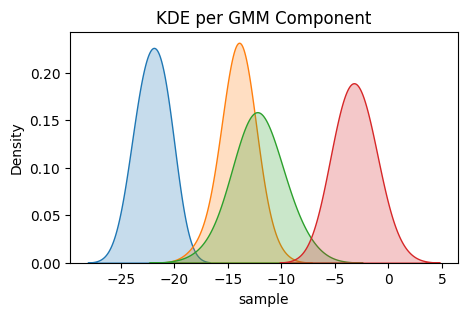

In [22]:
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples, gaussian_range, num_centers)

In [24]:
gmm_center.shape

(4, 10)

In [25]:
# save centers 
pd.DataFrame(gmm_center).to_csv(os.path.join(output_data_folder, 'gmm_centers.csv'), index=False)

In [26]:
test = pd.read_csv(os.path.join(output_data_folder, 'gmm_centers.csv'))
test

,0,1,2,3,4,5,6,7,8,9
0,-22.263103,-26.791420,-25.608137,-22.875141,-22.113024,-24.643839,-22.773918,-20.188190,-22.670362,-26.679230
1,-13.754743,-18.469534,-15.450809,-14.333987,-17.618246,-19.350779,-14.350102,-17.350260,-13.968052,-18.404713
2,-12.391428,-9.462513,-9.185410,-12.954509,-11.911643,-12.322986,-7.891878,-9.135715,-8.958535,-10.974284
3,-3.046547,-5.814248,-4.456916,-0.359265,0.700492,-0.067539,-2.246403,-0.194167,-1.067997,-5.441456
